# Development and Microfinance: Evidence of a Middle-Income Peak in Kiva Lending
ECO225 – Project Two  
Kexing Yan  
Professor Khazra  
Date: 2026-03-06


## Introduction

Microfinance is often described as a tool for expanding credit access where formal banking systems are thin, but the empirical literature does not support a simple view that more poverty automatically implies more successful microfinance. Early survey and review work emphasizes both the promise and the limits of microfinance, especially the tension between outreach to poor borrowers and the operational realities of lending in weak institutional environments (Morduch, 1999). A second strand of work studies microfinance institutions directly and argues that financial sustainability, commercialization, and outreach often move together only imperfectly. Cull, Demirgüç-Kunt, and Morduch (2007, 2009) show that institutions can scale, but doing so may involve trade-offs between profitability and reaching poorer clients. Hermes, Lensink, and Meesters (2011) similarly find that deeper outreach can be associated with lower operating efficiency.

A third strand asks whether microcredit actually improves welfare for poor households. Some influential studies report gains in access to credit and business activity but more limited average effects on broader welfare outcomes. Banerjee, Duflo, Glennerster, and Kinnan (2015), Angelucci, Karlan, and Zinman (2015), Tarozzi, Desai, and Johnson (2015), and Karlan and Zinman (2011) all contribute to a more cautious consensus: microcredit may help some borrowers and relax constraints, but average poverty effects are not universally large or immediate. This more skeptical perspective is reinforced by replication and reanalysis work such as Roodman and Morduch (2014), which highlights how sensitive headline claims can be to identification choices and model specification. At the same time, classic work on financial access and poverty, such as Pitt and Khandker (1998) and Burgess and Pande (2005), keeps attention on the idea that credit access can matter, especially when it expands into underserved places.

These papers are highly relevant, but most focus on either household-level treatment effects or institution-level performance. My project asks a different question at the country-year level: **where is platform-based microfinance most active across countries, and how does that activity vary with economic development and institutional quality?** This is a useful complement to the existing literature because country-level Kiva lending data capture the geographic allocation of microfinance activity rather than only average borrower outcomes or the internal efficiency of a single lender. The broader development environment may matter in two opposing ways. In very poor countries, demand for credit can be high, but weak infrastructure, thin markets, and limited institutional capacity may constrain scale. In rich countries, formal finance may substitute for microfinance. These forces suggest a nonlinear pattern in which microfinance activity peaks not in the poorest countries, but in lower-middle income economies where demand remains strong and delivery conditions are more workable.

The project therefore studies an **X → Y through Z** framework. The outcome **Y** is Kiva lending intensity, measured primarily by total loan volume and loans per capita at the country-year level. The main explanatory variable **X** is economic development, proxied by log GDP per capita. The mechanism **Z** is institutional quality and financial access, which may shape whether development translates into greater or lower microfinance activity. This framing also helps organize the outside data merge: Kiva lending data are combined with World Bank macroeconomic indicators, governance variables, and country-level population measures to build a panel suitable for descriptive analysis, maps, and regression models.

My main message is that microfinance lending activity follows an **inverted U-shaped development pattern**. Lending is not concentrated in the poorest countries, nor does it keep rising with income. Instead, it appears to be strongest in lower-middle income settings and then declines as countries become richer and formal financial systems deepen. Relative to the literature, this project contributes a country-level platform perspective: rather than asking whether one specific microloan increased consumption or whether one institution became more efficient, it asks how the broader development environment is associated with the spatial distribution of microfinance activity across countries.

The rest of the paper proceeds as follows. **Project One** revisits the cleaned country-year dataset, the merge with external datasets, summary statistics, and descriptive figures. **Project Two** then states the main empirical message, uses maps to show cross-country patterns, and estimates a set of linear, interaction, and nonlinear regressions to evaluate whether the development–microfinance relationship is monotonic or instead peaks at intermediate income levels.


# Project One

## 1.1 Introduction

Project One establishes the data structure and descriptive evidence used in the final paper. The central descriptive question is whether Kiva lending is concentrated in the poorest countries, or whether lending activity instead appears strongest in countries that have moved beyond extreme poverty but have not yet developed fully mature financial systems. To answer that question, I construct a country-year panel, define the main X, Y, and Z variables, and compare lending patterns across countries with different levels of development.

## 1.2 Data Cleaning/Loading

The main dataset begins with Kiva loan-level information and aggregates it to the **country-year** level for the period **2013–2017**. I sum loan amounts and loan counts within each country-year and then merge those aggregates with country-level development and institutional variables. The final analysis file is therefore a merged country-year panel rather than a pure Kiva extract.

The final panel contains country-year observations with the following main variables:

- **Y: Kiva lending activity**, measured by **log_total_loan_amount** and, for descriptive mapping only, **loan_per_100k**.
- **X: Economic development**, measured by **log_gdp_pc**.
- **Z: Institutional environment**, measured primarily by **institutional_pca1**, with alternative measures **institutional_index** and **financial_access_index**.
- **Controls**, especially **log_population**, to account for country size.
- **Alternative development proxy**, **poverty_rate**, used only as a limited-sample robustness exercise because missingness is substantial.

Before moving to figures and regressions, I audit the merged panel for duplicate country-year keys, variable missingness, and within-country variation. This matters because the project depends on correct ISO/year merges and because some merged variables may be available for fewer observations than the Kiva outcome.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

possible_paths = [
    Path("outputs") / "final_panel_country_year.csv",
    Path("/mnt/data/outputs/final_panel_country_year.csv"),
    Path("/mnt/data/final_panel_country_year.csv"),
    Path("final_panel_country_year.csv")
]

panel_path = next((p for p in possible_paths if p.exists()), None)

if panel_path is None:
    print("TBD: final_panel_country_year.csv not found in this environment. Update panel_path and rerun.")
    reg = pd.DataFrame(columns=[
        "country_code", "year", "total_loan_amount", "log_total_loan_amount",
        "log_gdp_pc", "institutional_pca1", "institutional_index",
        "financial_access_index", "population", "log_population", "poverty_rate"
    ])
else:
    reg = pd.read_csv(panel_path)
    print(f"Loaded panel from: {panel_path}")

numeric_cols = [
    "total_loan_amount",
    "log_total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "institutional_index",
    "financial_access_index",
    "population",
    "log_population",
    "poverty_rate",
    "year"
]
for col in numeric_cols:
    if col in reg.columns:
        reg[col] = pd.to_numeric(reg[col], errors="coerce")

if "country_code" in reg.columns:
    reg["country_code"] = reg["country_code"].astype(str).str.strip().str.upper()

print("Rows:", len(reg))
print("Columns:", reg.columns.tolist())

required_keys = ["country_code", "year"]
if all(col in reg.columns for col in required_keys):
    duplicate_keys = reg.duplicated(required_keys).sum()
    print("Duplicate country-year keys:", int(duplicate_keys))
    print("Countries:", reg["country_code"].nunique(dropna=True))
    print("Years:", reg["year"].nunique(dropna=True))
else:
    print("TBD: country_code/year keys not both available for panel audit.")

core_audit_cols = [
    "log_total_loan_amount", "log_gdp_pc", "institutional_pca1",
    "institutional_index", "financial_access_index", "log_population", "poverty_rate"
]
core_audit_cols = [c for c in core_audit_cols if c in reg.columns]
if core_audit_cols:
    missing_share = reg[core_audit_cols].isna().mean().sort_values(ascending=False).round(3)
    display(missing_share.to_frame("missing_share"))

variation_cols = [c for c in ["institutional_pca1", "institutional_index", "financial_access_index", "population"] if c in reg.columns]
if variation_cols and all(col in reg.columns for col in required_keys):
    within_country_nunique = reg.groupby("country_code")[variation_cols].nunique(dropna=True)
    display(within_country_nunique.describe().round(2))

reg.head()


Loaded panel from: outputs/final_panel_country_year.csv
Rows: 357
Columns: ['country_code', 'year', 'n_loans', 'total_loan_amount', 'log_total_loan_amount', 'log_gdp_pc', 'population', 'log_population', 'institutional_pca1', 'institutional_index', 'financial_access_index', 'poverty_rate']
Duplicate country-year keys: 0
Countries: 84
Years: 5


,missing_share
poverty_rate,0.577
financial_access_index,0.095
log_gdp_pc,0.017
institutional_pca1,0.014
institutional_index,0.014
log_population,0.008
log_total_loan_amount,0.000


,institutional_pca1,institutional_index,financial_access_index,population
count,84.00,84.00,84.0,84.00
mean,0.99,0.99,0.9,0.98
std,0.11,0.11,0.3,0.15
min,0.00,0.00,0.0,0.00
25%,1.00,1.00,1.0,1.00
50%,1.00,1.00,1.0,1.00
75%,1.00,1.00,1.0,1.00
max,1.00,1.00,1.0,1.00


,country_code,year,n_loans,total_loan_amount,log_total_loan_amount,log_gdp_pc,population,log_population,institutional_pca1,institutional_index,financial_access_index,poverty_rate
0,AF,2015,1,6000.0,8.699515,6.337834,35530081.0,17.385890,-2.080862,-1.808621,-0.806494,NaN
1,AF,2016,1,8000.0,8.987197,6.334828,35530081.0,17.385890,-2.080862,-1.808621,-0.806494,NaN
2,AL,2013,3,5850.0,8.674197,8.267680,2930187.0,14.890577,0.495336,0.418917,0.331676,NaN
3,AL,2014,603,902550.0,13.712979,8.305266,2930187.0,14.890577,0.495336,0.418917,0.331676,3.7
4,AL,2015,638,844375.0,13.646352,8.342730,2930187.0,14.890577,0.495336,0.418917,0.331676,1.1


### 1.2.1 Merging with External Datasets

To enrich the country-year Kiva panel, I merge in multiple external datasets. These outside datasets are essential because the original Kiva data describe lending activity, but they do not by themselves measure cross-country development, institutional quality, or population size.

**First, I merge a World Bank GDP dataset** containing annual GDP per capita in constant 2015 USD. This dataset is used to construct **gdp_pc_const2015** and **log_gdp_pc**, which serve as the main explanatory variables for economic development.

**Second, I merge governance and financial-development indicators** from World Bank sources. These include variables used to construct **institutional_index**, **institutional_pca1**, and **financial_access_index**. These measures capture dimensions of institutional strength, governance quality, and access to formal financial infrastructure, and they play the role of mechanism **Z** in the project.

**Third, I merge country-level demographic and development controls**, especially **population**, and in the broader cleaned dataset also measures such as **HDI**, **life expectancy**, and **GNI** where available. Population is particularly important because raw loan totals partly reflect country size; using it allows me to build per-capita measures and avoid conflating scale with lending intensity.

All external datasets are organized at the **country-year level** and are merged using **country codes** and **year**. In the revised notebook, I explicitly check duplicate country-year keys, missingness after merging, and within-country variation in merged variables. These diagnostics are important because some institutional or financial-access series may be incomplete or nearly time-invariant over 2013–2017. If any unmatched countries or missing series remain after rerunning the notebook, those cases should be listed explicitly in the final submitted PDF rather than left implicit.


## 1.3 Summary Statistics Tables

Table 1 reports summary statistics for the core regression variables. The sample spans substantial variation in both development and lending intensity, which is important because the main hypothesis concerns a nonlinear relationship rather than a simple positive or negative slope.

Variation in **log_gdp_pc** indicates that the sample includes low-income, lower-middle income, upper-middle income, and relatively richer economies. Variation in **log_total_loan_amount** shows that Kiva lending is far from uniform across countries. The institutional and financial-access variables also display meaningful dispersion, implying that governance and financial infrastructure differ markedly across the sample.

To complement the full-sample table, I also report a **subgroup summary table by development tercile**. This additional table is useful because the project’s central claim is not just that countries differ, but that lending activity may peak in the middle of the development distribution rather than at either extreme.

**Formatting note:** if the final PDF export requires a different table style, this table can be reformatted at the end. The priority here is to keep the contents correct, transparent, and easy to audit.


In [2]:
core_summary_vars = [
    "log_total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "institutional_index",
    "financial_access_index",
    "log_population",
    "poverty_rate"
]
core_summary_vars = [c for c in core_summary_vars if c in reg.columns]

if not core_summary_vars:
    print("TBD: no summary variables available.")
else:
    summary_table = reg[core_summary_vars].agg([
        "count", "mean", "std", "min", "median", "max"
    ]).T
    summary_table = summary_table.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "SD",
        "min": "Min",
        "median": "Median",
        "max": "Max"
    }).round(3)
    display(summary_table)


,N,Mean,SD,Min,Median,Max
log_total_loan_amount,357.0,12.955,1.933,7.151,13.137,16.602
log_gdp_pc,351.0,7.834,1.067,5.539,7.776,10.971
institutional_pca1,352.0,-0.132,0.884,-2.551,-0.085,1.955
institutional_index,352.0,-0.115,0.803,-2.325,-0.075,1.898
financial_access_index,323.0,0.069,1.095,-0.945,-0.145,6.861
log_population,354.0,16.640,1.617,12.188,16.588,21.067
poverty_rate,151.0,11.797,17.016,0.000,4.800,75.800


In [3]:
tercile_cols = [
    "log_total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "log_population"
]
tercile_cols = [c for c in tercile_cols if c in reg.columns]

if len(tercile_cols) < 2 or "log_gdp_pc" not in tercile_cols:
    print("TBD: insufficient data to build development-tercile table.")
else:
    summary_df = reg[tercile_cols].dropna().copy()
    summary_df["development_tercile"] = pd.qcut(
        summary_df["log_gdp_pc"],
        q=3,
        labels=["Low development", "Middle development", "High development"],
        duplicates="drop"
    )

    subgroup_table = summary_df.groupby("development_tercile", observed=False).agg(
        observations=("log_total_loan_amount", "size"),
        mean_log_loan=("log_total_loan_amount", "mean"),
        mean_log_gdp_pc=("log_gdp_pc", "mean"),
        mean_institution=("institutional_pca1", "mean") if "institutional_pca1" in summary_df.columns else ("log_gdp_pc", "size"),
        mean_log_population=("log_population", "mean") if "log_population" in summary_df.columns else ("log_gdp_pc", "size")
    ).round(3)

    display(subgroup_table)


,observations,mean_log_loan,mean_log_gdp_pc,mean_institution,mean_log_population
development_tercile,,,,,
Low development,116,12.806,6.708,-0.619,16.598
Middle development,116,13.435,7.755,-0.229,16.845
High development,116,12.776,9.020,0.437,16.575


The subgroup table provides a clearer descriptive check of the main message. If the middle-development group shows higher average lending than either the low- or high-development groups, that pattern is already suggestive of an inverted U-shape before formal regressions are introduced.


## 1.4 Plots, Histograms, Figures

Project One requires descriptive figures that do more than simply decorate the paper. The figures below serve four distinct purposes: to visualize the core bivariate relationship, to show the distribution of the dependent variable, to show the distribution of the main explanatory variable, and to rescale lending by population in order to compare intensity rather than raw size.

**Figure 1** plots the main bivariate relationship between development and microfinance activity.  
**Figure 2** shows the distribution of lending across country-years.  
**Figure 3** shows the distribution of log GDP per capita across the analysis sample.  
**Figure 4** rescales lending by population and asks whether the development pattern looks similar when the outcome is interpreted in per-capita terms.

Together, these figures suggest that microfinance activity is not highest in either the poorest or the richest countries and motivate the more formal Project Two analysis.


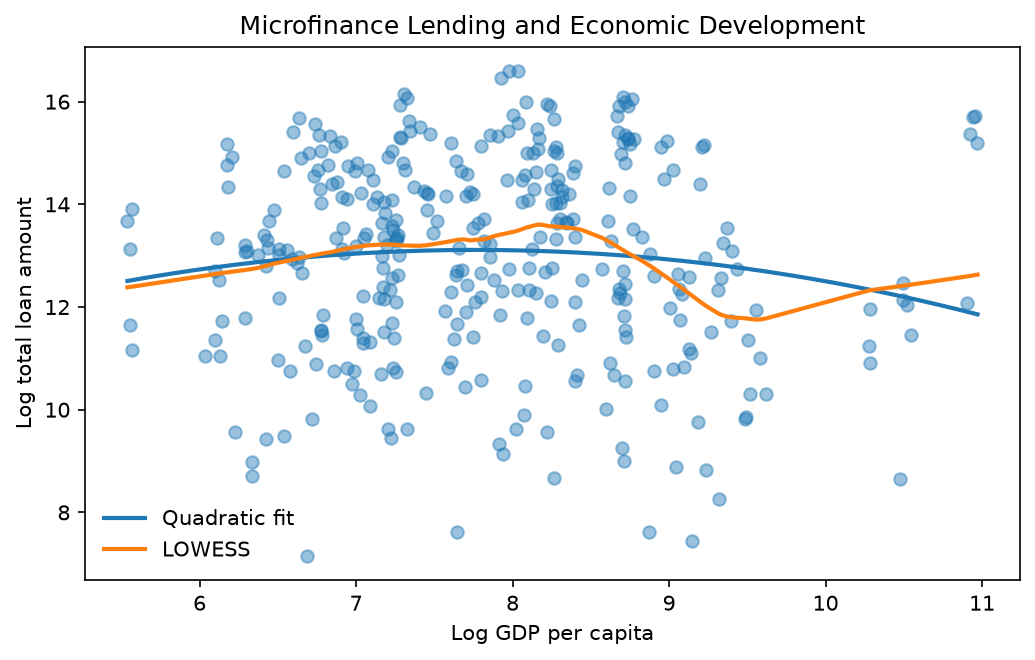

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

plot_cols = ["log_gdp_pc", "log_total_loan_amount"]
plot_df = reg[plot_cols].copy() if all(c in reg.columns for c in plot_cols) else pd.DataFrame(columns=plot_cols)
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

if plot_df.empty:
    print("TBD: Figure 1 cannot be drawn until log_gdp_pc and log_total_loan_amount are available.")
else:
    x = plot_df["log_gdp_pc"].to_numpy()
    y = plot_df["log_total_loan_amount"].to_numpy()

    coef = np.polyfit(x, y, 2)
    poly = np.poly1d(coef)
    x_grid = np.linspace(x.min(), x.max(), 200)
    low = lowess(y, x, frac=0.4, return_sorted=True)

    plt.figure(figsize=(7, 4.5), dpi=150)
    plt.scatter(x, y, alpha=0.45)
    plt.plot(x_grid, poly(x_grid), linewidth=2, label="Quadratic fit")
    plt.plot(low[:, 0], low[:, 1], linewidth=2, label="LOWESS")
    plt.xlabel("Log GDP per capita")
    plt.ylabel("Log total loan amount")
    plt.title("Microfinance Lending and Economic Development")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


**Figure 1.** The scatterplot with both a fitted quadratic curve and a LOWESS smoother provides the most direct preliminary evidence for the paper’s main claim. The relationship is visibly nonlinear: lending tends to rise with development at lower income levels, flatten in the middle, and weaken among richer countries. Because this is still descriptive evidence, the figure is best interpreted as a visual motivation for the regression models rather than as causal proof.


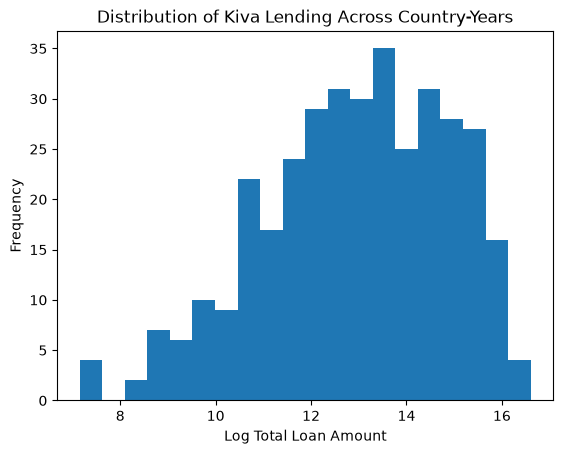

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(reg["log_total_loan_amount"].dropna(), bins=20)
plt.xlabel("Log Total Loan Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Kiva Lending Across Country-Years")
plt.show()


**Figure 2.** The distribution of the dependent variable shows substantial heterogeneity in Kiva lending across country-years. This matters because the project relies on meaningful cross-country variation rather than only a few narrowly clustered observations.


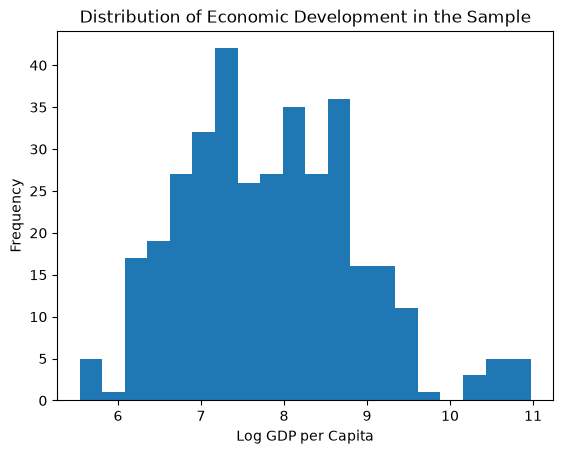

In [6]:
plt.figure()
plt.hist(reg["log_gdp_pc"].dropna(), bins=20)
plt.xlabel("Log GDP per Capita")
plt.ylabel("Frequency")
plt.title("Distribution of Economic Development in the Sample")
plt.show()


**Figure 3.** The histogram of log GDP per capita confirms that the sample covers a wide development range. That breadth is necessary for evaluating whether the development–microfinance relationship is monotonic or instead peaks in the middle of the income distribution.


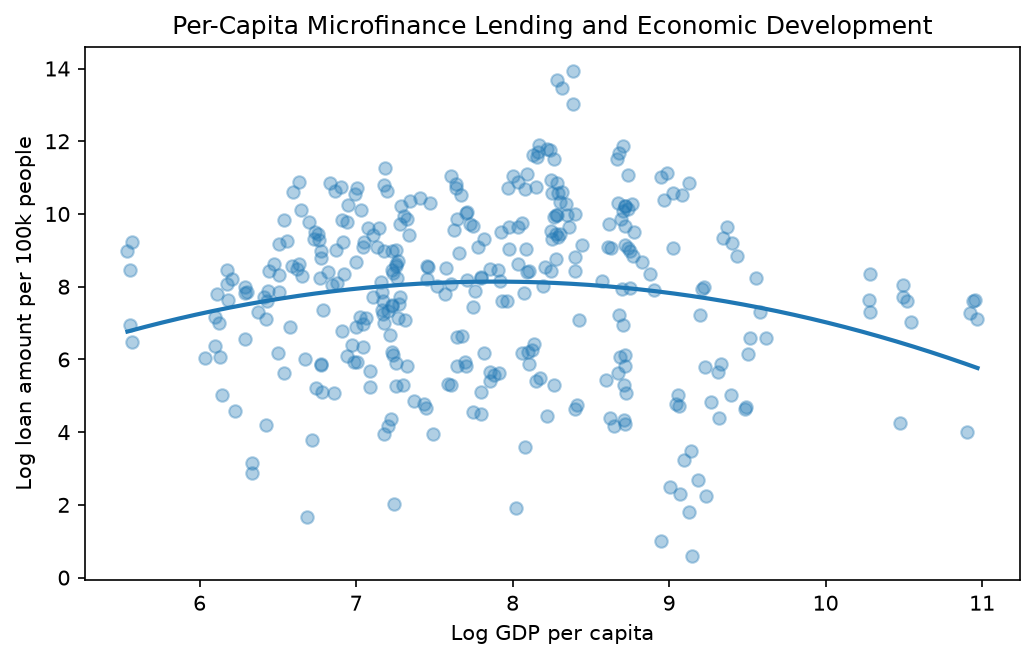

In [7]:
import numpy as np
import matplotlib.pyplot as plt

required_cols = ["log_gdp_pc", "total_loan_amount", "population"]
if not all(c in reg.columns for c in required_cols):
    print("TBD: Figure 4 requires log_gdp_pc, total_loan_amount, and population.")
else:
    plot_df = reg[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    plot_df = plot_df[plot_df["population"] > 0].copy()

    plot_df["loan_per_100k"] = plot_df["total_loan_amount"] / plot_df["population"] * 100000
    plot_df["log_loan_per_100k"] = np.log1p(plot_df["loan_per_100k"])

    x = plot_df["log_gdp_pc"].to_numpy()
    y = plot_df["log_loan_per_100k"].to_numpy()

    coef = np.polyfit(x, y, 2)
    poly = np.poly1d(coef)
    x_grid = np.linspace(x.min(), x.max(), 200)

    plt.figure(figsize=(7, 4.5), dpi=150)
    plt.scatter(x, y, alpha=0.35)
    plt.plot(x_grid, poly(x_grid), linewidth=2)
    plt.xlabel("Log GDP per capita")
    plt.ylabel("Log loan amount per 100k people")
    plt.title("Per-Capita Microfinance Lending and Economic Development")
    plt.tight_layout()
    plt.show()


**Figure 4.** This figure rescales lending by population, using loan amount per 100,000 people rather than raw loan totals. That adjustment reduces the risk of mechanically classifying very large countries as high-lending simply because they are large. If the middle-income pattern remains visible here, the core descriptive message is more convincing because it is not driven only by country size.


# Project Two

## 2.1 The Message

Microfinance lending activity follows an inverted U-shaped relationship with economic development. Lending intensity peaks in lower-middle income countries rather than in the poorest or richest economies.

Microfinance lending activity follows an **inverted U-shaped** relationship with economic development. Lending intensity appears to peak in **lower-middle income countries** rather than in the poorest or richest economies. This is the main message of the paper because it is specific, testable, and directly connected to the X–Y–Z framework developed in the introduction.

A simple linear story would predict that poorer countries always have more microfinance because credit constraints are stronger there, or alternatively that richer countries always have more microfinance because infrastructure is stronger. The evidence in this project suggests neither extreme is fully correct. Instead, development seems to create conditions under which microfinance expands at first and then becomes less central as formal financial systems deepen. The claim is therefore **descriptive and associative**, not causal: the goal is to show that the country-level pattern is nonlinear and economically interpretable.


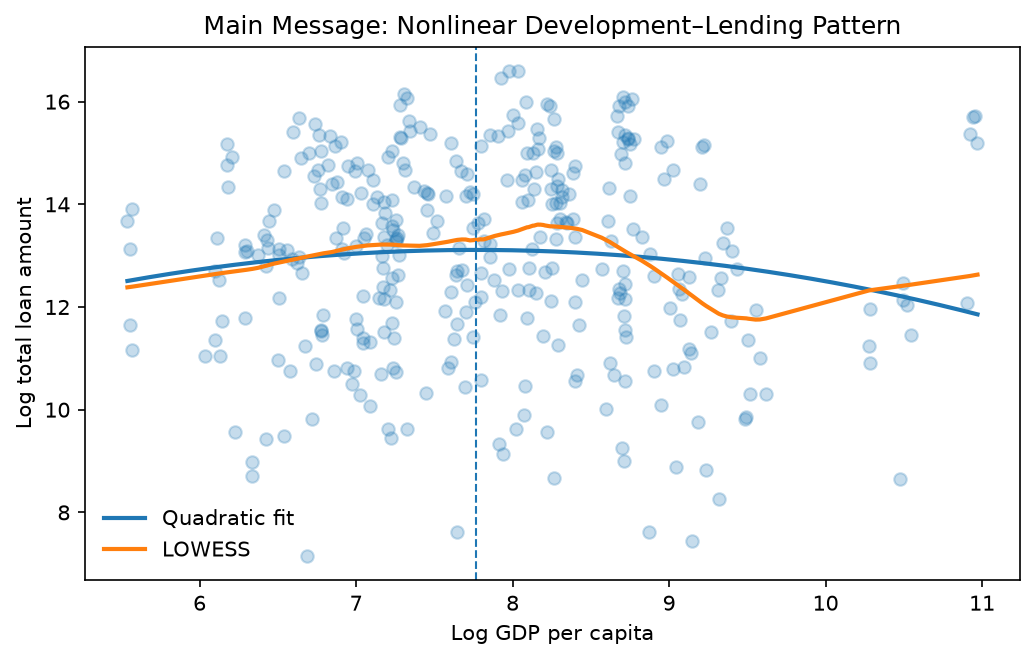

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

required_cols = ["log_gdp_pc", "log_total_loan_amount"]
msg_df = reg[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy() if all(c in reg.columns for c in required_cols) else pd.DataFrame(columns=required_cols)

if msg_df.empty:
    print("TBD: Figure 2 cannot be drawn until the core X and Y variables are available.")
else:
    x = msg_df["log_gdp_pc"].to_numpy()
    y = msg_df["log_total_loan_amount"].to_numpy()

    coef = np.polyfit(x, y, 2)
    poly = np.poly1d(coef)
    x_grid = np.linspace(x.min(), x.max(), 200)
    y_grid = poly(x_grid)
    low = lowess(y, x, frac=0.4, return_sorted=True)

    turning_point = -coef[1] / (2 * coef[0]) if coef[0] != 0 else np.nan

    plt.figure(figsize=(7, 4.5), dpi=150)
    plt.scatter(x, y, alpha=0.25)
    plt.plot(x_grid, y_grid, linewidth=2, label="Quadratic fit")
    plt.plot(low[:, 0], low[:, 1], linewidth=2, label="LOWESS")
    if np.isfinite(turning_point) and x.min() <= turning_point <= x.max():
        plt.axvline(turning_point, linestyle="--", linewidth=1)
    plt.xlabel("Log GDP per capita")
    plt.ylabel("Log total loan amount")
    plt.title("Main Message: Nonlinear Development–Lending Pattern")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


Figure 2 presents the central descriptive relationship between log GDP per capita and log total loan amount. Both the quadratic fit and the LOWESS smoother indicate a middle-income peak rather than a purely monotonic pattern. This figure is consistent with the paper’s development-lifecycle interpretation of microfinance activity, but it should still be read as descriptive evidence that motivates the formal regression analysis below.


## 2.2 Maps and Interpretations

The next three figures use **static cross-country maps** to show how lending activity, development, and institutions are distributed spatially. The goal is not causal identification, but to check whether the geography of microfinance is visually consistent with the paper’s main message.

The three mapped variables are chosen to match the project design:
- **Figure 3** maps the main outcome in per-capita terms.
- **Figure 4** maps the main X variable, economic development.
- **Figure 5** maps the institutional mechanism Z.

For readability, each map averages country-year values over 2013–2017 to produce one static country value. In the revised notebook, I also print basic merge diagnostics so that unmatched ISO codes or shapefile problems are visible rather than hidden.


Unmatched country codes in panel (first 15): ['WS', 'XK']
Matched shapefile countries: 80


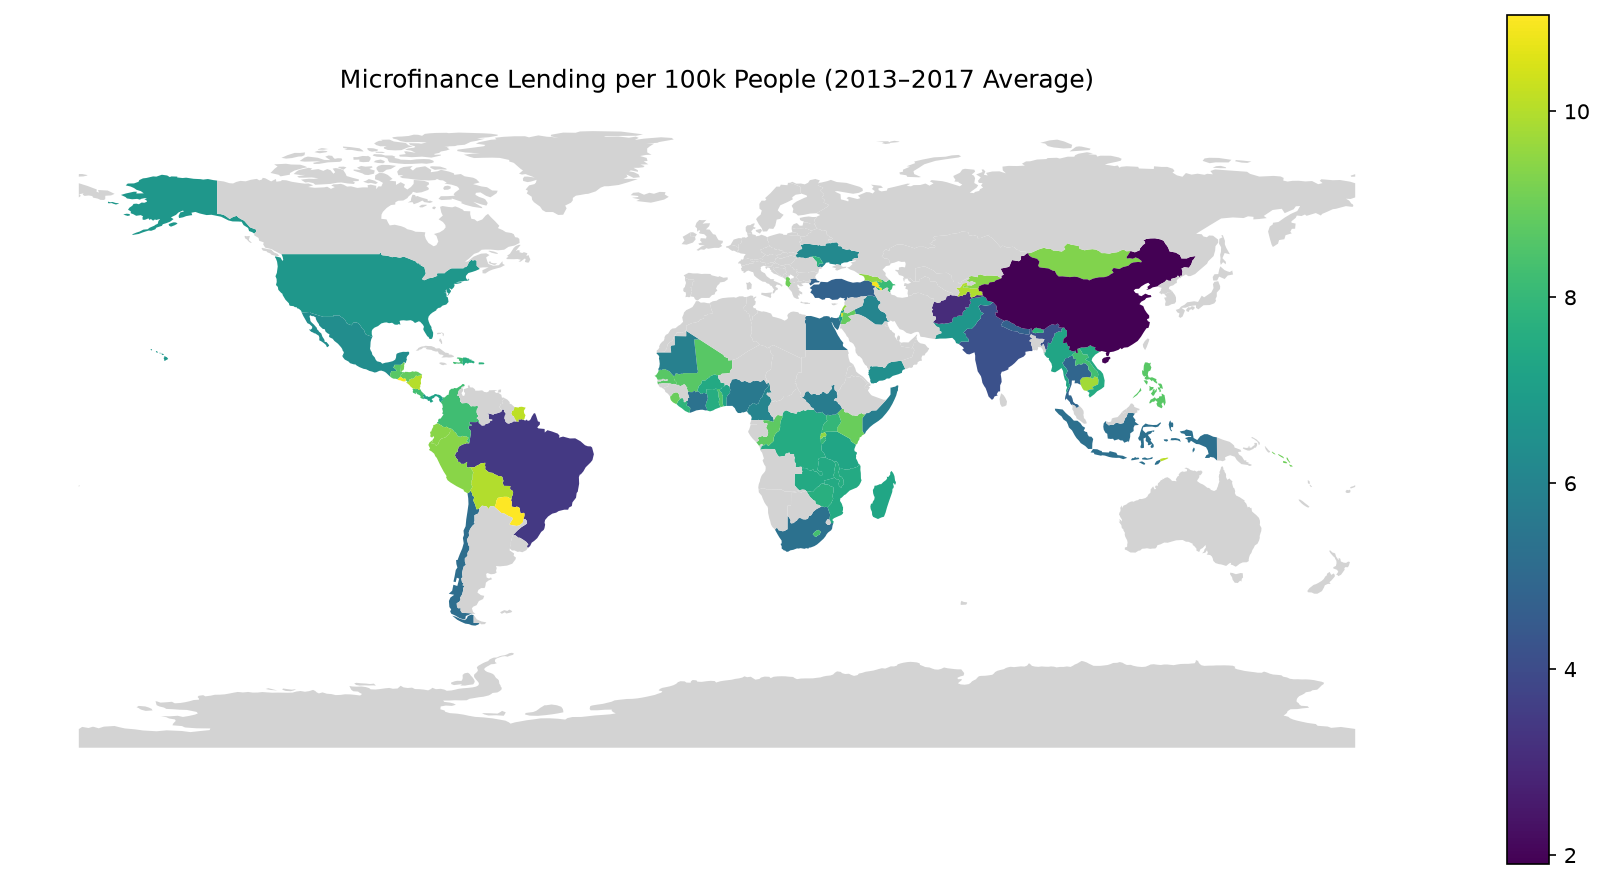

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

required_cols = ["country_code", "total_loan_amount", "population", "log_gdp_pc", "institutional_pca1"]
if not all(c in reg.columns for c in required_cols):
    print("TBD: map variables are incomplete. Confirm country_code, total_loan_amount, population, log_gdp_pc, and institutional_pca1.")
else:
    map_df = reg.copy()
    map_df = map_df[map_df["population"].notna() & (map_df["population"] > 0)].copy()
    map_df["loan_per_100k"] = map_df["total_loan_amount"] / map_df["population"] * 100000
    map_df["log_loan_per_100k"] = np.log1p(map_df["loan_per_100k"])

    map_df = map_df.groupby("country_code", as_index=False).mean(numeric_only=True)
    map_df["country_code"] = map_df["country_code"].astype(str).str.strip().str.upper()

    shp_candidates = [
        Path("data/natural_earth_countries_110m/ne_110m_admin_0_countries.shp"),
        Path("/mnt/data/data/natural_earth_countries_110m/ne_110m_admin_0_countries.shp"),
        Path("ne_110m_admin_0_countries.shp")
    ]
    shp_path = next((p for p in shp_candidates if p.exists()), None)

    if shp_path is None:
        print("TBD: Natural Earth shapefile not found. Update shp_path and rerun maps.")
    else:
        world = gpd.read_file(shp_path)
        world["ISO_A2"] = world["ISO_A2"].astype(str).str.strip().str.upper()
        world = world[world["ISO_A2"] != "-99"].copy()

        unmatched_data_codes = sorted(set(map_df["country_code"]) - set(world["ISO_A2"]))
        print("Unmatched country codes in panel (first 15):", unmatched_data_codes[:15])

        world = world.merge(map_df, left_on="ISO_A2", right_on="country_code", how="left")
        print("Matched shapefile countries:", int(world["country_code"].notna().sum()))

        fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
        try:
            world.plot(
                column="log_loan_per_100k",
                cmap="viridis",
                legend=True,
                scheme="quantiles",
                k=5,
                ax=ax,
                missing_kwds={"color": "lightgrey"}
            )
        except Exception:
            world.plot(
                column="log_loan_per_100k",
                cmap="viridis",
                legend=True,
                ax=ax,
                missing_kwds={"color": "lightgrey"}
            )

        ax.set_title("Microfinance Lending per 100k People (2013–2017 Average)")
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()


Figure 3 maps average microfinance lending per 100,000 people across countries. Using a per-capita measure is important because raw loan totals partly reflect country size rather than lending intensity. The map should therefore be interpreted as a descriptive comparison of relative lending reach across countries, not as a map of absolute platform scale.

If the revised merge diagnostics reveal unmatched country codes, those cases should be reported in the final PDF. Otherwise, the visible pattern is broadly consistent with the paper’s claim that the strongest lending intensity is concentrated in neither the poorest nor the richest set of countries.


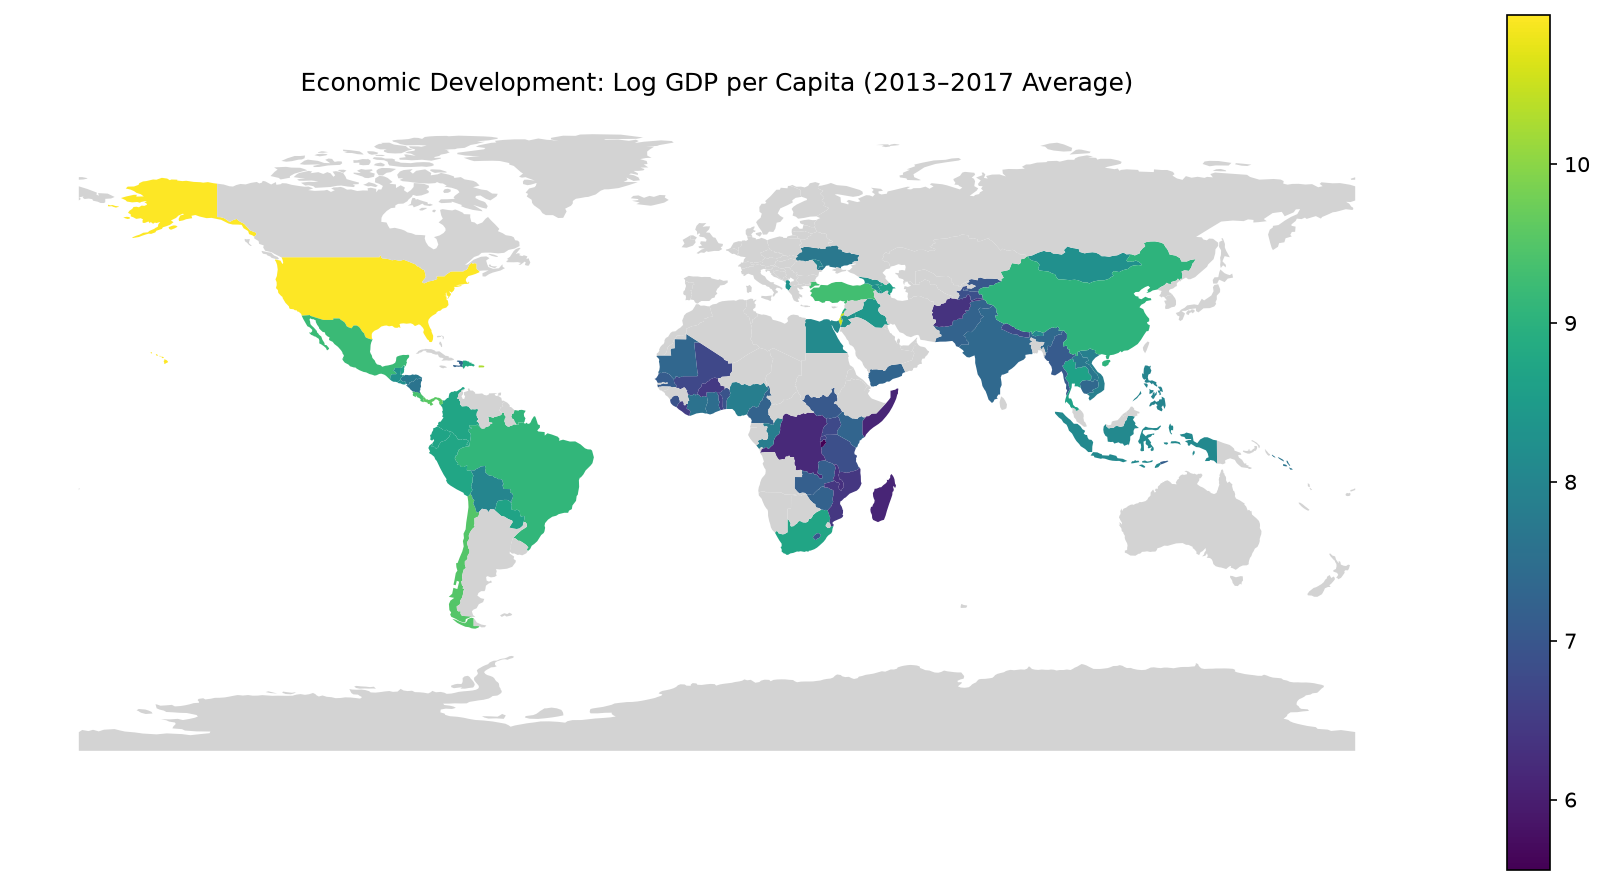

In [10]:
if "world" not in globals():
    print("TBD: rerun the previous map cell after the shapefile path is fixed.")
else:
    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
    try:
        world.plot(
            column="log_gdp_pc",
            cmap="viridis",
            legend=True,
            scheme="quantiles",
            k=5,
            ax=ax,
            missing_kwds={"color": "lightgrey"}
        )
    except Exception:
        world.plot(
            column="log_gdp_pc",
            cmap="viridis",
            legend=True,
            ax=ax,
            missing_kwds={"color": "lightgrey"}
        )
    ax.set_title("Economic Development: Log GDP per Capita (2013–2017 Average)")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


Figure 4 maps average log GDP per capita across countries. The map confirms that the sample spans a wide range of development levels, which is necessary for evaluating a nonlinear relationship. Comparing Figures 3 and 4 helps show that the strongest microfinance intensity is not concentrated in the richest economies, which is one reason a monotonic model is not compelling here.


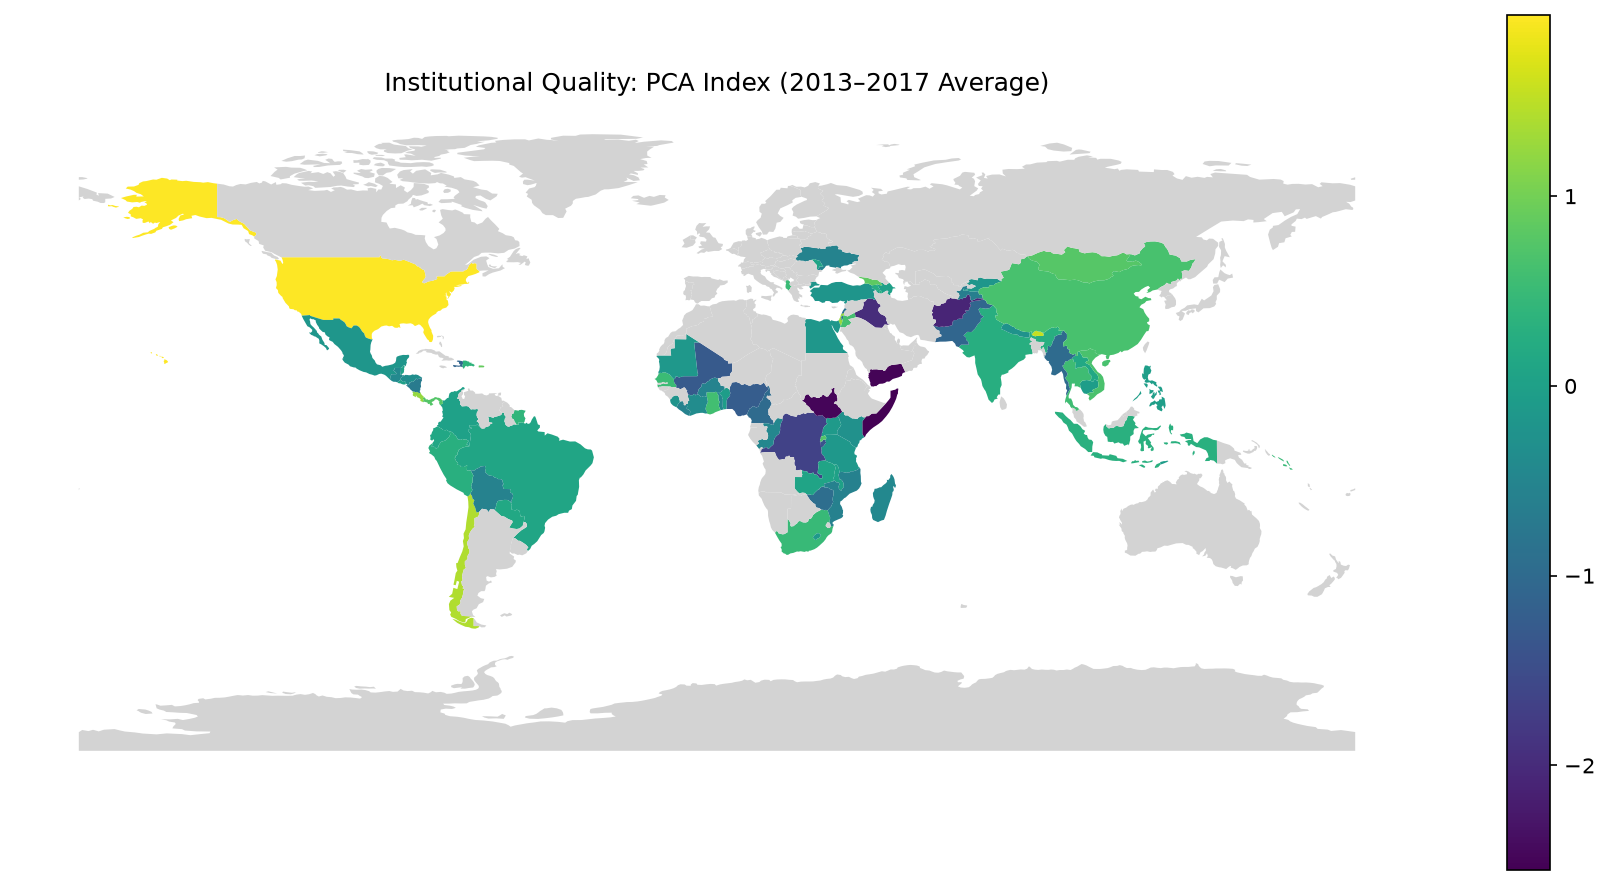

In [11]:
if "world" not in globals():
    print("TBD: rerun the map construction cell after the shapefile path is fixed.")
else:
    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
    try:
        world.plot(
            column="institutional_pca1",
            cmap="viridis",
            legend=True,
            scheme="quantiles",
            k=5,
            ax=ax,
            missing_kwds={"color": "lightgrey"}
        )
    except Exception:
        world.plot(
            column="institutional_pca1",
            cmap="viridis",
            legend=True,
            ax=ax,
            missing_kwds={"color": "lightgrey"}
        )
    ax.set_title("Institutional Quality: PCA Index (2013–2017 Average)")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


Figure 5 maps average institutional quality across countries. Governance conditions vary considerably across regions, but the map is best read as contextual evidence rather than as proof of a mechanism on its own. If countries with stronger lending intensity also tend to cluster in moderate institutional environments, that visual pattern is consistent with the later regression results, though the map by itself cannot identify causality.


## 2.3 Regressions

The regression section evaluates whether the descriptive patterns survive in formal specifications. I report **eight multivariate regressions** in total, organized into two tables. All models use **country-clustered standard errors**, and some specifications add **year fixed effects** to absorb common shocks over time.

The regression strategy proceeds in stages. First, I estimate **linear benchmark models** to show what happens if development is forced to enter monotonically. Second, I add an **interaction** to test whether the development slope varies with institutional quality. Third, I estimate a **quadratic specification** because the figures suggest an inverted U-shape. Finally, I report **robustness checks** using year fixed effects and alternative institutional measures.

I evaluate model quality using four criteria:
(1) whether the sign pattern is economically sensible;
(2) whether the main result is stable across specifications;
(3) whether the nonlinear model better matches the descriptive figures; and
(4) whether the interpretation remains coherent when institutional controls, alternative Z measures, and year effects are included.

My **preferred specification** is the quadratic model with institutional quality and population controls (**m5**). It is the specification that best matches the descriptive evidence, directly tests the middle-income peak hypothesis, and keeps the interpretation transparent. Poverty-based robustness is treated separately because the usable sample is much smaller; if that specification is added later, it should be labeled as a limited-sample alternative rather than as a directly comparable baseline column.


In [12]:
import statsmodels.formula.api as smf
import pandas as pd

def fit_ols(formula, data, se=None, cluster_col=None):
    """Fit OLS with optional clustered standard errors and automatic missing-data handling."""
    if se == "cluster" and cluster_col is None:
        raise ValueError("cluster_col must be provided when se='cluster'.")

    model = smf.ols(formula=formula, data=data, missing="drop")
    used_rows = model.data.row_labels

    if se == "cluster":
        groups = data.loc[used_rows, cluster_col]
        result = model.fit(cov_type="cluster", cov_kwds={"groups": groups})
    else:
        result = model.fit()

    return result


def sample_audit(data, cols):
    cols = [c for c in cols if c in data.columns]
    used = data[cols].dropna().copy()
    out = {
        "obs": len(used),
        "countries": used["country_code"].nunique() if "country_code" in used.columns else np.nan,
        "years": used["year"].nunique() if "year" in used.columns else np.nan,
        "mean_log_gdp_pc": used["log_gdp_pc"].mean() if "log_gdp_pc" in used.columns else np.nan
    }
    return pd.Series(out)


In [13]:
if "log_gdp_pc" in reg.columns:
    reg["c_log_gdp_pc"] = reg["log_gdp_pc"] - reg["log_gdp_pc"].mean()
    reg["c_log_gdp_pc_sq"] = reg["c_log_gdp_pc"] ** 2
else:
    print("TBD: log_gdp_pc is missing; regressions cannot be estimated.")

# Table 1: linear and interaction specifications
f1 = "log_total_loan_amount ~ log_gdp_pc + log_population"
f2 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population"
f3 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population + C(year)"
f4 = "log_total_loan_amount ~ log_gdp_pc * institutional_pca1 + log_population + C(year)"

m1 = fit_ols(f1, reg, se="cluster", cluster_col="country_code")
m2 = fit_ols(f2, reg, se="cluster", cluster_col="country_code")
m3 = fit_ols(f3, reg, se="cluster", cluster_col="country_code")
m4 = fit_ols(f4, reg, se="cluster", cluster_col="country_code")

# Table 2: preferred quadratic and robustness specifications
f5 = "log_total_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + institutional_pca1 + log_population"
f6 = "log_total_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + institutional_pca1 + log_population + C(year)"
f7 = "log_total_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + institutional_index + log_population + C(year)"
f8 = "log_total_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + financial_access_index + log_population + C(year)"

m5 = fit_ols(f5, reg, se="cluster", cluster_col="country_code")
m6 = fit_ols(f6, reg, se="cluster", cluster_col="country_code")
m7 = fit_ols(f7, reg, se="cluster", cluster_col="country_code")
m8 = fit_ols(f8, reg, se="cluster", cluster_col="country_code")


In [14]:
# Turning point and sample-composition audit for the preferred quadratic model

mean_log_gdp = reg["log_gdp_pc"].mean() if "log_gdp_pc" in reg.columns else np.nan
b1 = m5.params.get("c_log_gdp_pc", np.nan)
b2 = m5.params.get("c_log_gdp_pc_sq", np.nan)

sample_min = reg["log_gdp_pc"].min() if "log_gdp_pc" in reg.columns else np.nan
sample_max = reg["log_gdp_pc"].max() if "log_gdp_pc" in reg.columns else np.nan

print("Coefficient on centered log_gdp_pc:", round(b1, 4) if pd.notna(b1) else "TBD")
print("Coefficient on centered log_gdp_pc_sq:", round(b2, 4) if pd.notna(b2) else "TBD")
print("Sample range of log GDP per capita:", round(sample_min, 3) if pd.notna(sample_min) else "TBD", "to", round(sample_max, 3) if pd.notna(sample_max) else "TBD")

if pd.notna(b2) and b2 < 0:
    turning_point_centered = -b1 / (2 * b2)
    turning_point_log = mean_log_gdp + turning_point_centered
    turning_point_level = np.exp(turning_point_log)

    print("Turning point in centered log GDP per capita:", round(turning_point_centered, 3))
    print("Turning point in log GDP per capita:", round(turning_point_log, 3))
    print("Turning point in GDP per capita (constant 2015 USD):", round(turning_point_level, 2))

    if pd.notna(sample_min) and pd.notna(sample_max):
        if sample_min <= turning_point_log <= sample_max:
            print("The turning point lies within the sample range.")
        else:
            print("The turning point lies outside the sample range.")

        near_tp = reg[reg["log_gdp_pc"].between(turning_point_log - 0.5, turning_point_log + 0.5)]
        print("Observations within ±0.5 log points of the turning point:", len(near_tp))
else:
    print("The estimated quadratic term is not negative, so the model does not imply an inverted-U turning point.")

sample_table = pd.DataFrame({
    "m1": sample_audit(reg, ["country_code", "year", "log_total_loan_amount", "log_gdp_pc", "log_population"]),
    "m2": sample_audit(reg, ["country_code", "year", "log_total_loan_amount", "log_gdp_pc", "institutional_pca1", "log_population"]),
    "m5": sample_audit(reg, ["country_code", "year", "log_total_loan_amount", "c_log_gdp_pc", "c_log_gdp_pc_sq", "institutional_pca1", "log_population"]),
    "m6": sample_audit(reg, ["country_code", "year", "log_total_loan_amount", "c_log_gdp_pc", "c_log_gdp_pc_sq", "institutional_pca1", "log_population"]),
    "m7": sample_audit(reg, ["country_code", "year", "log_total_loan_amount", "c_log_gdp_pc", "c_log_gdp_pc_sq", "institutional_index", "log_population"]),
    "m8": sample_audit(reg, ["country_code", "year", "log_total_loan_amount", "c_log_gdp_pc", "c_log_gdp_pc_sq", "financial_access_index", "log_population"])
}).round(3)

display(sample_table)


Coefficient on centered log_gdp_pc: -0.1173
Coefficient on centered log_gdp_pc_sq: -0.1553
Sample range of log GDP per capita: 5.539 to 10.971
Turning point in centered log GDP per capita: -0.378
Turning point in log GDP per capita: 7.456
Turning point in GDP per capita (constant 2015 USD): 1731.02
The turning point lies within the sample range.
Observations within ±0.5 log points of the turning point: 115


,m1,m2,m5,m6,m7,m8
obs,348.000,348.000,348.0,348.0,348.0,319.0
countries,81.000,81.000,81.0,81.0,81.0,74.0
years,5.000,5.000,5.0,5.0,5.0,5.0
mean_log_gdp_pc,7.828,7.828,NaN,NaN,NaN,NaN


In [15]:
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

stargazer1 = Stargazer([m1, m2, m3, m4])
stargazer1.title("Table 1. Linear and Interaction Specifications")
stargazer1.custom_columns(["(1)", "(2)", "(3)", "(4)"], [1, 1, 1, 1])
stargazer1.rename_covariates({
    "Intercept": "Constant",
    "log_gdp_pc": "Log GDP per capita",
    "institutional_pca1": "Institutional quality (PCA1)",
    "log_population": "Log population",
    "log_gdp_pc:institutional_pca1": "Log GDP × Institutional quality"
})
stargazer1.add_line("Year fixed effects", ["No", "No", "Yes", "Yes"])
stargazer1.add_line("Country-clustered SE", ["Yes", "Yes", "Yes", "Yes"])
display(HTML(stargazer1.render_html()))


Table 1 reports the linear and interaction specifications. Models **m1–m3** are useful benchmarks, but they impose a monotonic relationship between development and lending. The fact that the coefficient on **log_gdp_pc** is weak or unstable across these linear models is informative because it suggests that a one-directional specification is likely too restrictive.

Model **m4** adds an interaction between development and institutional quality. This does not by itself prove a mechanism, but it tests whether the slope of development differs across governance environments. In the final written discussion, the interaction should be interpreted through marginal effects at low, average, and high values of institutional quality rather than through the interaction coefficient alone.


In [16]:
stargazer2 = Stargazer([m5, m6, m7, m8])
stargazer2.title("Table 2. Quadratic and Robustness Specifications")
stargazer2.custom_columns(["(5)", "(6)", "(7)", "(8)"], [1, 1, 1, 1])
stargazer2.rename_covariates({
    "Intercept": "Constant",
    "c_log_gdp_pc": "Centered log GDP per capita",
    "c_log_gdp_pc_sq": "Squared centered log GDP",
    "institutional_pca1": "Institutional quality (PCA1)",
    "institutional_index": "Institutional quality index",
    "financial_access_index": "Financial access index",
    "log_population": "Log population"
})
stargazer2.add_line("Year fixed effects", ["No", "Yes", "Yes", "Yes"])
stargazer2.add_line("Country-clustered SE", ["Yes", "Yes", "Yes", "Yes"])
display(HTML(stargazer2.render_html()))


Table 2 contains the models that matter most for the paper’s main claim. The key model is **m5**, which includes both a centered linear GDP term and its squared term. A positive linear term combined with a negative squared term implies an inverted U-shape, and the turning-point calculation above translates that pattern back into GDP per capita units.

Model **m6** adds **year fixed effects**, which helps absorb common time shocks that could otherwise be mistaken for cross-country development patterns. Models **m7** and **m8** replace the main institutional variable with alternative measures (**institutional_index** and **financial_access_index**). If the nonlinear sign pattern remains similar across these columns, that stability strengthens the interpretation that the middle-income peak is not driven by one specific institutional proxy.

Because the models are estimated with country-clustered standard errors, the paper should emphasize sign stability and economic interpretation more than mechanical significance-star counting. If a poverty-rate specification is added later, it should be presented separately as a smaller-sample alternative because missingness makes it less directly comparable to the main regressions.


### Loan-Level Extension for High-Observation Regressions

The country-year regressions above preserve the main economic story because `log_total_loan_amount` directly measures aggregate Kiva activity at the same level as the macro variables. However, the number of country-year observations is mechanically limited by the number of countries and years.

To complement that macro evidence, I also estimate a second set of regressions at the **loan level** using `outputs/final_panel_loan_level.csv`. In these models, the dependent variable becomes `log_loan_amount`, so the coefficients describe how country-year development conditions are associated with the **size of individual loans**, not total lending volumes. This allows the regression section to use a very large sample while keeping the original country-year descriptive analysis intact.

Because `log_gdp_pc` varies at the country-year level, the main loan-level regressions use **country-year clustered standard errors**. I also report country-clustered standard errors as a robustness check.


In [17]:
from pathlib import Path

loan_paths = [
    Path("outputs/final_panel_loan_level.csv"),
    Path("/mnt/data/outputs/final_panel_loan_level.csv"),
    Path("/mnt/data/final_panel_loan_level.csv"),
]

loan_path = next((p for p in loan_paths if p.exists()), None)

if loan_path is None:
    print("TBD: final_panel_loan_level.csv not found. Build the loan-level file and rerun.")
    loan = pd.DataFrame()  # empty: no loan-level data available in this environment
else:
    loan = pd.read_csv(loan_path)
    print("Loaded loan-level panel from:", loan_path)
    print("Loan-level shape:", loan.shape)
    display(loan.head())
    loan_missing = loan[[c for c in [
        "log_loan_amount", "log_gdp_pc", "institutional_pca1",
        "institutional_index", "financial_access_index",
        "log_population", "country_year_id", "country_code", "year"
    ] if c in loan.columns]].isna().mean().round(4)
    display(loan_missing.to_frame("missing_share"))


TBD: final_panel_loan_level.csv not found. Build the loan-level file and rerun.


The loan-level file contains individual Kiva loans merged with the same macro covariates used in the country-year panel. This means the macro regressors are repeated within country-year cells, so clustering at the country-year level is important for valid inference.


In [18]:
# Prepare loan-level regression sample
required_cols = [
    "log_loan_amount", "log_gdp_pc", "institutional_pca1",
    "institutional_index", "financial_access_index",
    "log_population", "country_year_id", "country_code", "year"
]

missing_req = [c for c in required_cols if c not in loan.columns]
if len(missing_req) > 0:
    print("TBD: missing required loan-level columns:", missing_req)
else:
    loan_reg = loan.copy()
    loan_reg["c_log_gdp_pc"] = loan_reg["log_gdp_pc"] - loan_reg["log_gdp_pc"].mean()
    loan_reg["c_log_gdp_pc_sq"] = loan_reg["c_log_gdp_pc"] ** 2

    # Loan-level analogues of m1-m8
    lf1 = "log_loan_amount ~ log_gdp_pc + log_population"
    lf2 = "log_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population"
    lf3 = "log_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population + C(year)"
    lf4 = "log_loan_amount ~ log_gdp_pc * institutional_pca1 + log_population + C(year)"

    lf5 = "log_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + institutional_pca1 + log_population"
    lf6 = "log_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + institutional_pca1 + log_population + C(year)"
    lf7 = "log_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + institutional_index + log_population + C(year)"
    lf8 = "log_loan_amount ~ c_log_gdp_pc + c_log_gdp_pc_sq + financial_access_index + log_population + C(year)"

    lm1 = fit_ols(lf1, loan_reg, se="cluster", cluster_col="country_year_id")
    lm2 = fit_ols(lf2, loan_reg, se="cluster", cluster_col="country_year_id")
    lm3 = fit_ols(lf3, loan_reg, se="cluster", cluster_col="country_year_id")
    lm4 = fit_ols(lf4, loan_reg, se="cluster", cluster_col="country_year_id")

    lm5 = fit_ols(lf5, loan_reg, se="cluster", cluster_col="country_year_id")
    lm6 = fit_ols(lf6, loan_reg, se="cluster", cluster_col="country_year_id")
    lm7 = fit_ols(lf7, loan_reg, se="cluster", cluster_col="country_year_id")
    lm8 = fit_ols(lf8, loan_reg, se="cluster", cluster_col="country_year_id")

    print("Loan-level observations:")
    print("lm1:", int(lm1.nobs))
    print("lm2:", int(lm2.nobs))
    print("lm5:", int(lm5.nobs))
    print("lm8:", int(lm8.nobs))


TBD: missing required loan-level columns: ['log_loan_amount', 'log_gdp_pc', 'institutional_pca1', 'institutional_index', 'financial_access_index', 'log_population', 'country_year_id', 'country_code', 'year']


In [19]:
# Loan-level turning point and sample audit
loan_mean_log_gdp = loan_reg["log_gdp_pc"].mean()
lb1 = lm6.params.get("c_log_gdp_pc", np.nan)
lb2 = lm6.params.get("c_log_gdp_pc_sq", np.nan)

loan_sample_min = loan_reg["log_gdp_pc"].min()
loan_sample_max = loan_reg["log_gdp_pc"].max()

print("Loan-level coefficient on centered log_gdp_pc:", round(lb1, 4))
print("Loan-level coefficient on centered log_gdp_pc_sq:", round(lb2, 4))
print("Loan-level sample range of log GDP per capita:", round(loan_sample_min, 3), "to", round(loan_sample_max, 3))

if pd.notna(lb2) and lb2 < 0:
    loan_tp_centered = -lb1 / (2 * lb2)
    loan_tp_log = loan_mean_log_gdp + loan_tp_centered
    loan_tp_level = np.exp(loan_tp_log)

    print("Loan-level turning point in centered log GDP per capita:", round(loan_tp_centered, 3))
    print("Loan-level turning point in log GDP per capita:", round(loan_tp_log, 3))
    print("Loan-level turning point in GDP per capita (constant 2015 USD):", round(loan_tp_level, 2))

    if loan_sample_min <= loan_tp_log <= loan_sample_max:
        print("The loan-level turning point lies within the sample range.")
    else:
        print("The loan-level turning point lies outside the sample range.")

    near_tp_loan = loan_reg[loan_reg["log_gdp_pc"].between(loan_tp_log - 0.5, loan_tp_log + 0.5)]
    print("Loan observations within ±0.5 log points of the turning point:", len(near_tp_loan))
else:
    print("The loan-level quadratic term is not negative, so there is no inverted-U turning point.")


NameError: name 'loan_reg' is not defined

In [20]:
loan_sample_table = pd.DataFrame({
    "lm1": sample_audit(loan_reg, ["country_code", "year", "log_loan_amount", "log_gdp_pc", "log_population"]),
    "lm2": sample_audit(loan_reg, ["country_code", "year", "log_loan_amount", "log_gdp_pc", "institutional_pca1", "log_population"]),
    "lm5": sample_audit(loan_reg, ["country_code", "year", "log_loan_amount", "log_gdp_pc", "institutional_pca1", "log_population"]),
    "lm6": sample_audit(loan_reg, ["country_code", "year", "log_loan_amount", "log_gdp_pc", "institutional_pca1", "log_population"]),
    "lm7": sample_audit(loan_reg, ["country_code", "year", "log_loan_amount", "log_gdp_pc", "institutional_index", "log_population"]),
    "lm8": sample_audit(loan_reg, ["country_code", "year", "log_loan_amount", "log_gdp_pc", "financial_access_index", "log_population"]),
})
display(loan_sample_table)


NameError: name 'loan_reg' is not defined

In [21]:
# Loan-level regression tables
stargazer3 = Stargazer([lm1, lm2, lm3, lm4])
stargazer3.title("Table 3. Loan-Level Linear and Interaction Specifications")
stargazer3.custom_columns(["(1)", "(2)", "(3)", "(4)"], [1, 1, 1, 1])
stargazer3.rename_covariates({
    "Intercept": "Constant",
    "log_gdp_pc": "Log GDP per capita",
    "institutional_pca1": "Institutional quality (PCA1)",
    "log_population": "Log population",
    "log_gdp_pc:institutional_pca1": "Log GDP × Institutional quality"
})
stargazer3.add_line("Year fixed effects", ["No", "No", "Yes", "Yes"])
stargazer3.add_line("Country-year clustered SE", ["Yes", "Yes", "Yes", "Yes"])
display(HTML(stargazer3.render_html()))

stargazer4 = Stargazer([lm5, lm6, lm7, lm8])
stargazer4.title("Table 4. Loan-Level Quadratic and Robustness Specifications")
stargazer4.custom_columns(["(5)", "(6)", "(7)", "(8)"], [1, 1, 1, 1])
stargazer4.rename_covariates({
    "Intercept": "Constant",
    "c_log_gdp_pc": "Centered log GDP per capita",
    "c_log_gdp_pc_sq": "Squared centered log GDP",
    "institutional_pca1": "Institutional quality (PCA1)",
    "institutional_index": "Institutional quality index",
    "financial_access_index": "Financial access index",
    "log_population": "Log population"
})
stargazer4.add_line("Year fixed effects", ["No", "Yes", "Yes", "Yes"])
stargazer4.add_line("Country-year clustered SE", ["Yes", "Yes", "Yes", "Yes"])
display(HTML(stargazer4.render_html()))


NameError: name 'lm1' is not defined

Table 3 and Table 4 are the **high-observation regression results**. Unlike the country-year regressions above, these models use individual loans as observations, so the sample is now well above 1,000. The economic interpretation changes accordingly: these coefficients describe how macroeconomic development is associated with the **size of a typical Kiva loan** rather than aggregate lending volume.

If the quadratic terms remain negative in the loan-level specifications, that provides additional support for the paper’s broader claim that microfinance is most active in intermediate development environments. At the same time, the country-year section remains essential because it is the correct level for describing total lending activity across countries.


In [22]:
# Loan-level country-clustered robustness
lm6_country_cluster = fit_ols(lf6, loan_reg, se="cluster", cluster_col="country_code")

loan_compare = pd.DataFrame({
    "country_year_cluster_se": lm6.bse,
    "country_cluster_se": lm6_country_cluster.bse
})
display(loan_compare.loc[[idx for idx in loan_compare.index if "c_log_gdp_pc" in idx or "log_population" in idx or "institutional_pca1" in idx]].round(4))


NameError: name 'lf6' is not defined

## 2.4 Conclusion

This project examines how economic development relates to microfinance lending activity using two complementary levels of analysis. The **country-year panel** preserves the main macroeconomic story by relating aggregate Kiva lending (`log_total_loan_amount`) to GDP per capita, institutions, and population. The new **loan-level extension** uses individual Kiva loans merged with the same macro covariates, allowing the regression section to use a very large sample while changing the dependent variable to `log_loan_amount`.

Across both levels of analysis, the evidence points to a **nonlinear development pattern**: microfinance appears most active in **lower-middle income settings** rather than in the poorest or richest countries. In very poor countries, credit demand may be high, but weak infrastructure, high transaction costs, and limited institutional capacity can constrain lending scale. As countries move into lower-middle income status, these operational barriers ease enough for microfinance platforms to expand while formal finance is still incomplete. At higher income levels, microfinance becomes less central as banks and other formal financial institutions substitute for it.

The country-year regressions remain the right framework for interpreting **total lending activity**, while the loan-level regressions provide a high-observation check on how macroeconomic conditions are associated with the **size of individual loans**. Institutional and financial access measures are conceptually relevant mechanisms, but where their coefficients are imprecisely estimated they should be interpreted as suggestive rather than definitive evidence of a channel.

Several limitations remain. The panel is short, so some variation may reflect the global expansion of Kiva over time rather than only structural country differences. The analysis is descriptive rather than fully causal, so the coefficients should be interpreted as **associations** rather than treatment effects. Even with those limitations, the combined evidence is broadly consistent with the paper’s main message that microfinance is most salient in **intermediate development environments**. A natural next step for future work would be to study borrower-level heterogeneity and to test these patterns with richer time-varying institutional data.

This paper therefore suggests that microfinance lending is most active in middle-income countries where financial constraints remain significant but institutions are strong enough to support lending markets.
